## Import Library

In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

## Config

In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
import os

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 20
SEED = 42

TRAIN_DIR = "DatasetBatikFix/train"
VAL_DIR   = "DatasetBatikFix/validation"
TEST_DIR  = "DatasetBatikFix/test"

## Augmentasi Data

In [30]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [31]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("Jumlah kelas:", len(class_names))

Found 2100 images belonging to 20 classes.
Found 600 images belonging to 20 classes.
Found 300 images belonging to 20 classes.
Jumlah kelas: 20


## Build Model

In [32]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))
x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

In [33]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
MODEL_DIR = "resnet_model"
os.makedirs(MODEL_DIR, exist_ok=True)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=2, verbose=1),
    ModelCheckpoint(os.path.join(MODEL_DIR, "best_stage1.keras"), save_best_only=True)
]

In [35]:
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 285s 4s/step - accuracy: 0.2067 - loss: 3.0366 - val_accuracy: 0.5717 - val_loss: 1.6288 - learning_rate: 1.0000e-04
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 427s 7s/step - accuracy: 0.5157 - loss: 1.6604 - val_accuracy: 0.7950 - val_loss: 0.9205 - learning_rate: 1.0000e-04
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 391s 6s/step - accuracy: 0.6829 - loss: 1.0918 - val_accuracy: 0.8700 - val_loss: 0.6200 - learning_rate: 1.0000e-04
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 399s 6s/step - accuracy: 0.7457 - loss: 0.8669 - val_accuracy: 0.8983 - val_loss: 0.4714 - learning_rate: 1.0000e-04
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 364s 6s/step - accuracy: 0.8014 - loss: 0.6908 - val_accuracy: 0.9067 - val_loss: 0.3945 - learning_rate: 1.0000e-04
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1297s 20s/step - accuracy: 0.8290 - loss: 0.6000 - val_accuracy: 0.9167 - val_loss: 0.3417 - learning_rate: 1.0000e-04
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 272s 4s/step - accuracy: 0.853

In [36]:
train_loss, train_acc = model.evaluate(
    train_generator, verbose =1
    )
val_loss, val_acc = model.evaluate(
    val_generator, verbose=1
    )

test_loss, test_acc = model.evaluate(
    test_generator, verbose=1
    )

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print (f"Train Accuracy : {train_acc:.4f}")
print (f"Train Loss : {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0.9890 - loss: 0.0524
19/19 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.9583 - loss: 0.1715
10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.9467 - loss: 0.1877
Validation Accuracy: 0.9583
Test Accuracy: 0.9467
Train Accuracy : 0.9890
Train Loss : 0.0524
Test Loss: 0.1877
Validation Loss: 0.1715


In [37]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

                     precision    recall  f1-score   support

       batik_betawi       0.93      0.93      0.93        15
batik_bokor_kencono       0.88      1.00      0.94        15
      batik_buketan       0.94      1.00      0.97        15
        batik_dayak       1.00      0.60      0.75        15
    batik_jlamprang       0.78      0.93      0.85        15
       batik_kawung       0.93      0.87      0.90        15
        batik_liong       1.00      0.93      0.97        15
 batik_mega_mendung       1.00      1.00      1.00        15
       batik_parang       1.00      1.00      1.00        15
   batik_sekarjagad       0.93      0.87      0.90        15
    batik_sidoluhur       0.83      1.00      0.91        15
    batik_sidomukti       1.00      0.93      0.97        15
    batik_sidomulyo       0.93      0.93      0.93        15
 batik_singa_barong       0.94      1.00      0.97        15
     batik_srikaton       1.00      1.00      1.00        15
    batik_tribusono    

In [42]:
from sklearn.metrics import classification_report
import pandas as pd

# buat classification report dalam bentuk dictionary
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names,
    output_dict=True
)

# ubah menjadi DataFrame
df_report = pd.DataFrame(report).transpose()

# simpan ke CSV
df_report.to_csv("classification_report_batik_ResNet50Ver2.csv")

print("Classification report berhasil disimpan ke classification_report_batik_ResNet50.csv")

Classification report berhasil disimpan ke classification_report_batik_ResNet50.csv


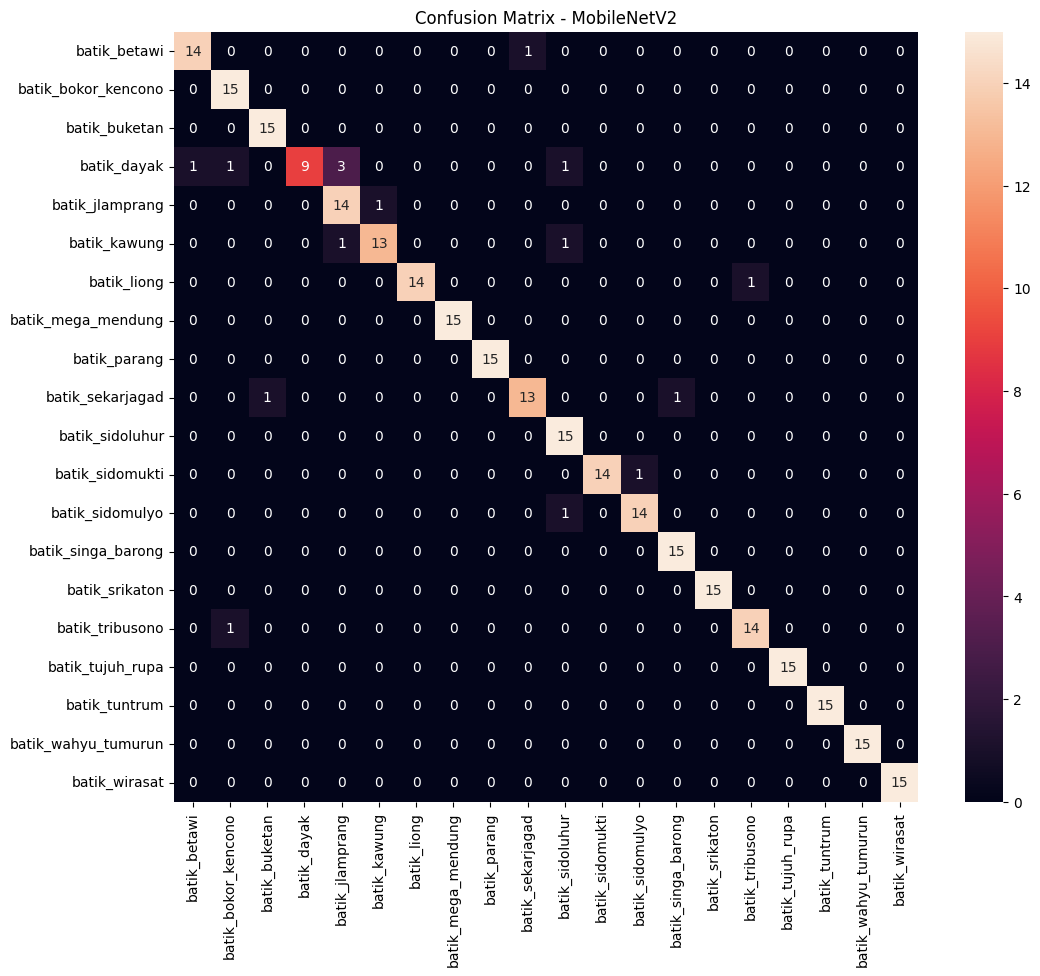

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix - MobileNetV2")
plt.show()

In [44]:
model.save(os.path.join(MODEL_DIR, "resnet50_batik_exp002.keras"))
print("Model saved.")

Model saved.


## fine tuning

In [45]:
for layer in base_model.layers[-80:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

MODEL_DIR = "resnet_model"
os.makedirs(MODEL_DIR, exist_ok=True)

callbacks_finetune = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,  # 🔥 lebih cepat stop
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(MODEL_DIR, "best_finetune.keras"),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

In [47]:
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,  # 🔥 cukup sedikit
    callbacks=callbacks_finetune
)

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8757 - loss: 0.4173
Epoch 1: val_loss improved from None to 0.18526, saving model to resnet_model\best_finetune.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 637s 9s/step - accuracy: 0.8729 - loss: 0.4123 - val_accuracy: 0.9483 - val_loss: 0.1853 - learning_rate: 5.0000e-06
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8769 - loss: 0.4041
Epoch 2: val_loss did not improve from 0.18526
66/66 ━━━━━━━━━━━━━━━━━━━━ 590s 9s/step - accuracy: 0.8867 - loss: 0.3750 - val_accuracy: 0.9483 - val_loss: 0.1986 - learning_rate: 5.0000e-06
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8847 - loss: 0.3461
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-06.

Epoch 3: val_loss did not improve from 0.18526
66/66 ━━━━━━━━━━━━━━━━━━━━ 567s 9s/step - accuracy: 0.8871 - loss: 0.3434 - val_accuracy: 0.9517 - val_loss: 0.1941 - learning_rate: 5.0000e-06
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step 

In [55]:
loss, acc = model.evaluate(test_generator)
print(f"Test Accuracy setelah fine tuning: {acc*100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.9467 - loss: 0.2051
Test Accuracy setelah fine tuning: 94.67%


In [56]:
train_loss, train_acc = model.evaluate(
    train_generator, verbose =1
    )
val_loss, val_acc = model.evaluate(
    val_generator, verbose=1
    )

test_loss, test_acc = model.evaluate(
    test_generator, verbose=1
    )

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print (f"Train Accuracy : {train_acc:.4f}")
print (f"Train Loss : {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.9824 - loss: 0.0660
19/19 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - accuracy: 0.9483 - loss: 0.1853
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.9467 - loss: 0.2051
Validation Accuracy: 0.9483
Test Accuracy: 0.9467
Train Accuracy : 0.9824
Train Loss : 0.0660
Test Loss: 0.2051
Validation Loss: 0.1853


In [50]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step


In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

                     precision    recall  f1-score   support

       batik_betawi       0.93      0.93      0.93        15
batik_bokor_kencono       0.94      1.00      0.97        15
      batik_buketan       1.00      1.00      1.00        15
        batik_dayak       1.00      0.60      0.75        15
    batik_jlamprang       0.78      0.93      0.85        15
       batik_kawung       0.93      0.93      0.93        15
        batik_liong       1.00      0.93      0.97        15
 batik_mega_mendung       1.00      1.00      1.00        15
       batik_parang       1.00      1.00      1.00        15
   batik_sekarjagad       0.93      0.87      0.90        15
    batik_sidoluhur       0.88      0.93      0.90        15
    batik_sidomukti       1.00      0.87      0.93        15
    batik_sidomulyo       0.93      0.93      0.93        15
 batik_singa_barong       0.94      1.00      0.97        15
     batik_srikaton       1.00      1.00      1.00        15
    batik_tribusono    

In [52]:
from sklearn.metrics import classification_report
import pandas as pd

# buat classification report dalam bentuk dictionary
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names,
    output_dict=True
)

# ubah menjadi DataFrame
df_report = pd.DataFrame(report).transpose()

# simpan ke CSV
df_report.to_csv("classification_report_batik_ResNet50Ver2FineTuning.csv")

print("Classification report berhasil disimpan ke classification_report_batik_ResNet50Ver2FineTuning.csv")

Classification report berhasil disimpan ke classification_report_batik_ResNet50Ver2FineTuning.csv


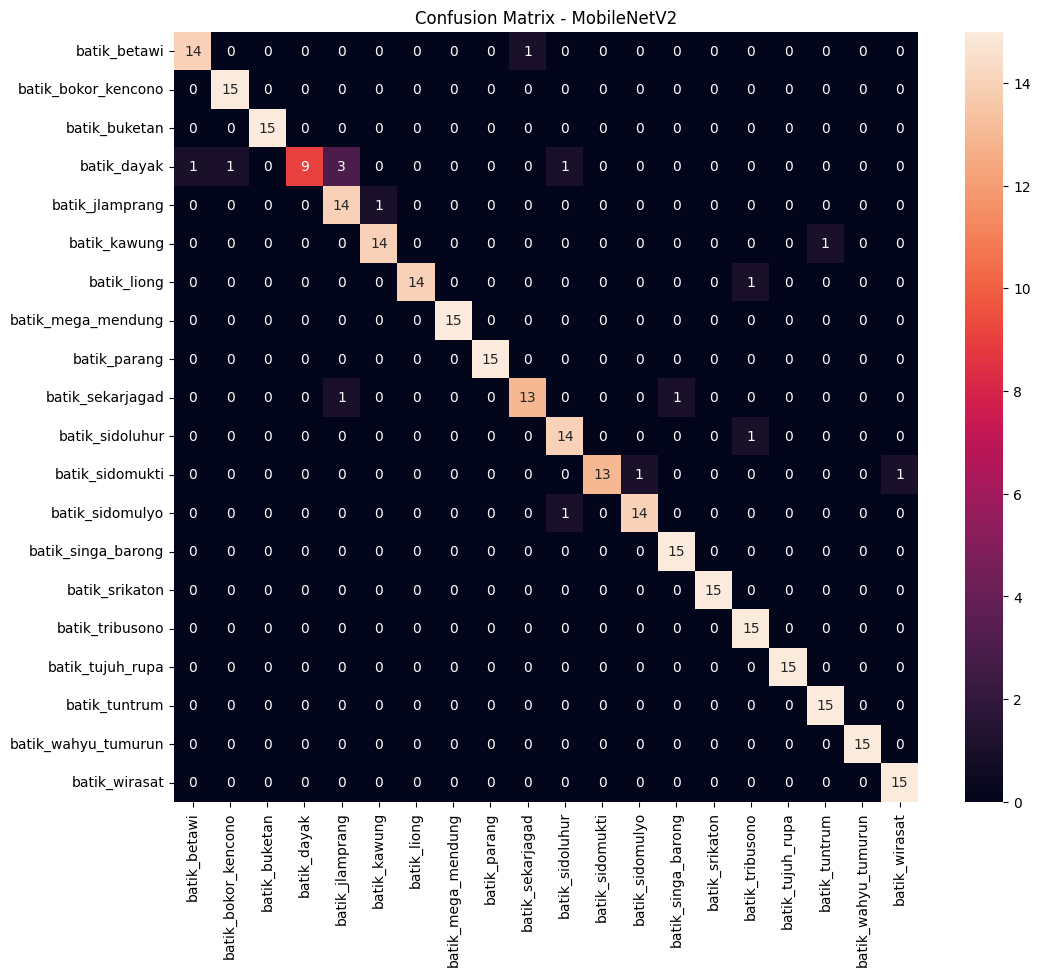

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix - MobileNetV2")
plt.show()

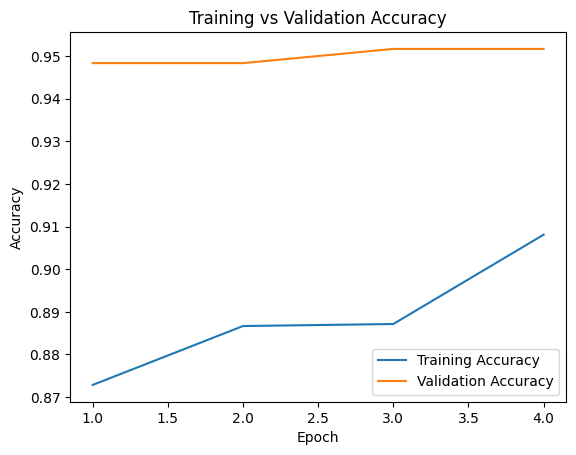

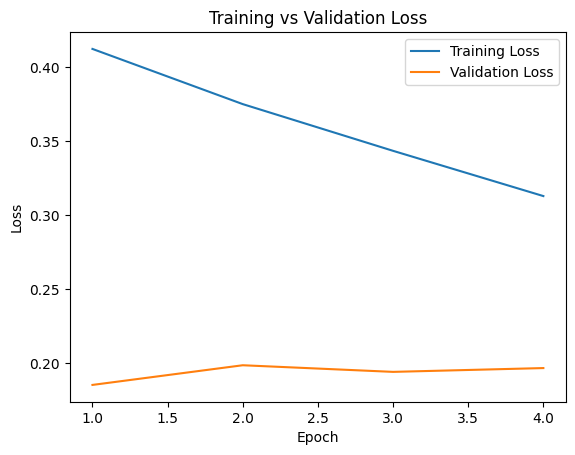

In [58]:
import matplotlib.pyplot as plt

acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']

loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

epochs = range(1, len(acc) + 1)

# Grafik Accuracy
plt.figure()
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Grafik Loss
plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [54]:
import sys
import tensorflow as tf

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__)

Python: 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
TensorFlow: 2.21.0
Keras: 3.12.1
